In [1]:
import spatialdata as sd
from napari_spatialdata import Interactive
from spatialdata.models import TableModel, ShapesModel
from shapely import Point

In [2]:
sdata = sd.read_zarr("Version 2 Baysor cell type Zarr//Sample_4D_annotated.zarr")
sdata

SpatialData object, with associated Zarr store: C:\Users\laure\Desktop\github\Masterpraktikum\main_task\Version 2 Baysor cell type Zarr\Sample_4D_annotated.zarr
├── Images
│     ├── '1_4D_tiff': DataTree[cyx] (4, 837, 620), (4, 418, 310), (4, 209, 155), (4, 104, 77)
│     └── 'morphology_focus': DataTree[cyx] (1, 34041, 42647), (1, 17020, 21323), (1, 8510, 10661), (1, 4255, 5330), (1, 2127, 2665)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
│     └── 'nucleus_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'Fibrous_cap': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Necrotic_core': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Noise':

In [3]:
circles = ShapesModel.parse(
    sdata.tables["Baysor"].obsm["spatial"],
    geometry=0,
    radius=1,
    index=sdata.tables["Baysor"].obs["cell"].copy(),
)

In [4]:
sdata.shapes["Baysor_circles"] = circles
adata = sdata.tables["Baysor"]
adata.obs["Baysor_circles"] = "Baysor_circles"
adata.obs["cell"] = adata.obs["cell"].astype(str)
adata = adata[adata.obs['cell'].notna()]
del sdata.tables["Baysor"]

In [5]:
table = TableModel.parse(adata, region_key="Baysor_circles", region="Baysor_circles", instance_key="cell")

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\spatialdata\models\models.py:957: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[cls.ATTRS_KEY] = attr
c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\spatialdata\models\models.py:959: UserWarning: Converting `region_key: Baysor_circles` to categorical dtype.
  return convert_region_column_to_categorical(adata)


In [6]:
sdata.tables["Baysor"] = table

In [7]:
sdata

SpatialData object, with associated Zarr store: C:\Users\laure\Desktop\github\Masterpraktikum\main_task\Version 2 Baysor cell type Zarr\Sample_4D_annotated.zarr
├── Images
│     ├── '1_4D_tiff': DataTree[cyx] (4, 837, 620), (4, 418, 310), (4, 209, 155), (4, 104, 77)
│     └── 'morphology_focus': DataTree[cyx] (1, 34041, 42647), (1, 17020, 21323), (1, 8510, 10661), (1, 4255, 5330), (1, 2127, 2665)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
│     └── 'nucleus_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'Baysor_circles': GeoDataFrame shape: (30450, 2) (2D shapes)
│     ├── 'Fibrous_cap': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Ne

In [8]:
Interactive(sdata)

2024-07-15 16:28:20.606 | INFO     | napari_spatialdata._viewer:add_sdata_points:660 - Subsampling points because the number of points exceeds the currently supported 100000. You can change this threshold with ```from napari_spatialdata.constants import config
config.POINT_THRESHOLD = <new_threshold>```


In [9]:
sdata

SpatialData object, with associated Zarr store: C:\Users\laure\Desktop\github\Masterpraktikum\main_task\Version 2 Baysor cell type Zarr\Sample_4D_annotated.zarr
├── Images
│     ├── '1_4D_tiff': DataTree[cyx] (4, 837, 620), (4, 418, 310), (4, 209, 155), (4, 104, 77)
│     └── 'morphology_focus': DataTree[cyx] (1, 34041, 42647), (1, 17020, 21323), (1, 8510, 10661), (1, 4255, 5330), (1, 2127, 2665)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
│     └── 'nucleus_labels': DataTree[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'Baysor_circles': GeoDataFrame shape: (30450, 2) (2D shapes)
│     ├── 'Fibrous_cap': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Ne

In [10]:
cell_coords = sdata.tables["Baysor"].obsm["spatial"]

In [11]:
Noise = sdata.shapes["Noise"].iloc[0, 0]
#Noise_2 = sdata.shapes["Noise_2"].iloc[0, 0]

In [12]:
def get_region(point, Noise):
    point = Point(point)
    if Noise.contains(point):
       return True
    #elif Noise_2.contains(point):
    #    return True
    else:
        return False

In [13]:
sdata.tables["Baysor"].obs['Noise'] = [get_region(coord, Noise) for coord in cell_coords]
sdata.tables["Baysor"].obs['Noise'] = sdata.tables["Baysor"].obs['Noise'].astype('category')

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


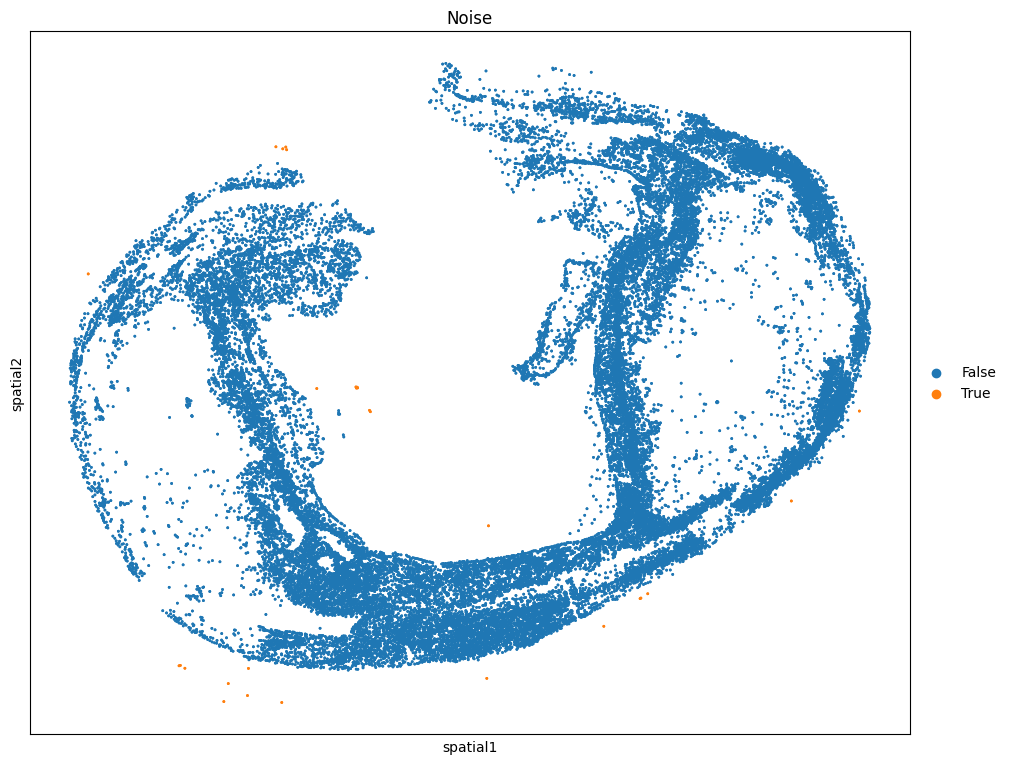

In [14]:
import squidpy as sq
sq.pl.spatial_scatter(
    sdata.tables["Baysor"], color="Noise", shape=None, figsize=(10, 10)
)

In [15]:
sdata.tables["Baysor"] = sdata.tables["Baysor"][sdata.tables["Baysor"].obs['Noise'] == False]

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\spatialdata\_core\_elements.py:116: UserWarning: Key `Baysor` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


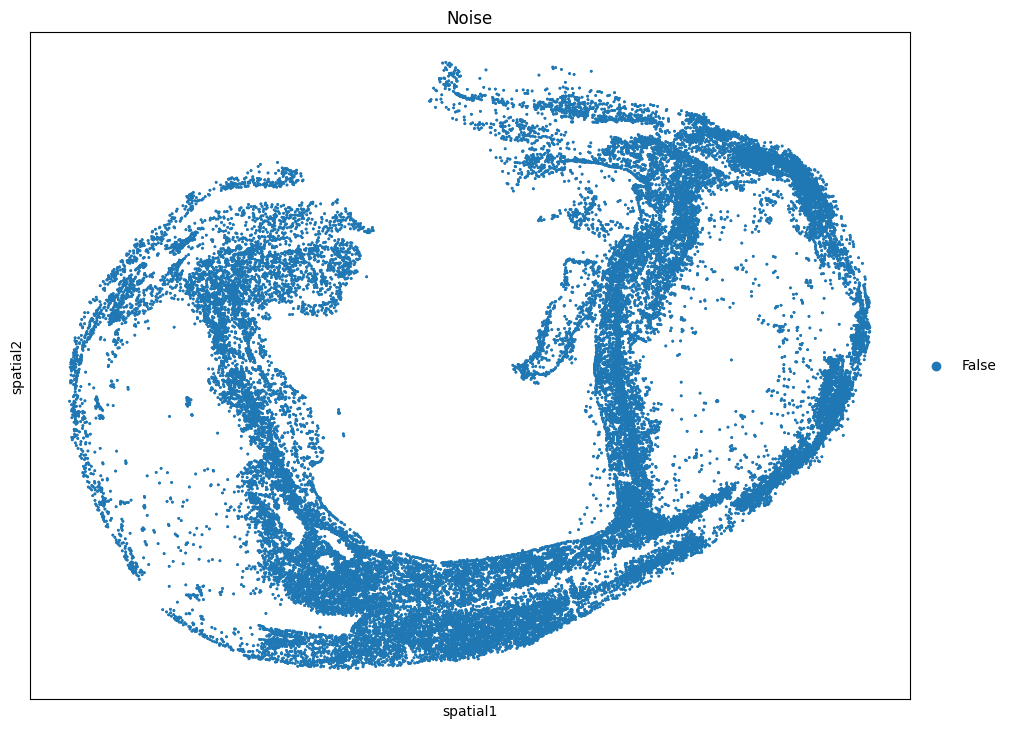

In [16]:
sq.pl.spatial_scatter(
    sdata.tables["Baysor"], color="Noise", shape=None, figsize=(10, 10)
)

In [17]:
sdata.shapes["Baysor_circles"].index = sdata.shapes["Baysor_circles"].index.astype(str)

In [18]:
sdata.write("Version 2 Baysor filtered Zarr//Sample_4D_filtered.zarr")

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside Version 2 Baysor filtered Zarr\Sample_4D_filtered.zarr). Please see the documentation of
         `is_self_contained()` to understand the implications of working with SpatialData objects that are not     
         self-contained.                                                                                           
INFO     The Zarr backing store has been changed from Version 2 Baysor cell type Zarr\Sample_4D_annotated.zarr the 
         new file path: Version 2 Baysor filtered Zarr\Sample_4D_filtered.zarr                                     
